# 3차시 실습 — 데이터 준비 (II) · 모델 개발

**인공지능플랫폼 실습/설계 · 2026학년도 2학기**

---

## 이 실습의 목적

머신러닝 시스템 설계 7단계 중 **3단계 후반부와 4단계**를 다룬다.

| 단계 | 이름 | 이 노트북에서 하는 일 |
|---|---|---|
| 3 | 데이터 준비 (II) | 피처 엔지니어링을 **하나의 Pipeline 객체**로 묶는다 |
| 4 | 모델 개발 | 기준선 → 단순 모델 → 복잡한 모델 순으로 비교하고 불균형에 대응한다 |

## 오늘의 두 가지 핵심

1. **데이터 누수(data leakage)** — `fit` 은 훈련 데이터에만, `transform` 은 모두에게
2. **성능의 기준선을 명확히 한다.** — 정확도 84%가 "학습한 것이 없다"는 뜻일 수 있다

## 최종 산출물

- 모델 비교 실험표 · 불균형 대응 비교표
- **모델 카드 (산출물 ④)**
- `hr_attrition_v1.pkl` — 전처리 + 모델이 함께 저장된 파이프라인 (4차시에서 사용)

---

## 수업진행

| 절 | 내용 |
|---|---|
| 0 | 2차시 결과 재현 |
| 1 | 피처 엔지니어링 (이상치 · 파생 피처) |
| 2 | 데이터 누수 실험 |
| 3 | ColumnTransformer + Pipeline |
| 4 | 분할과 교차검증 |
| 5 | 기준선 3종 |
| 6 | 모델 7종 비교 |
| 7 | 불균형 대응 3종 |
| 8 | 딥러닝(DNN) 비교 |
| 9 | 모델 해석 · 파이프라인 저장 |


In [1]:
# ============================================================
# 0. 환경 설정 (Colab 에서 런타임을 다시 연결할 때마다 실행)
# ============================================================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 한글 폰트 설정 (Colab) --------------------------------
import matplotlib.font_manager as fm, os, subprocess

def setup_korean_font():
    path = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
    if not os.path.exists(path):
        try:
            subprocess.run(["apt-get", "install", "-y", "fonts-nanum"],
                           check=False, capture_output=True)
        except Exception:
            pass
    if os.path.exists(path):
        fm.fontManager.addfont(path)
        plt.rcParams["font.family"] = "NanumBarunGothic"
    plt.rc("axes", unicode_minus=False)

setup_korean_font()
sns.set_theme(style="whitegrid", font=plt.rcParams["font.family"][0]
              if isinstance(plt.rcParams["font.family"], list) else plt.rcParams["font.family"])
plt.rc("axes", unicode_minus=False)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

RANDOM_STATE = 2026
DATA_URL = "http://joy-bae.github.io/HR-Employee-Attrition.csv"
print("환경 설정 완료 / pandas", pd.__version__)

환경 설정 완료 / pandas 2.2.3


---
# 0. 2차시 결과 재현

2차시에서 만든 **데이터 카드의 속성 유형 분류**를 그대로 가져온다.


In [4]:
df = pd.read_csv(DATA_URL)

TARGET = "Attrition"
COLUMN_TYPES = {
    "num_cont": ["Income_M", "p_SalaryHike"],
    "num_disc": ["Age", "Dist", "Companies", "YearsAtCompany", "YearsSinceLastPromotion"],
    "cat_ord":  ["Education", "JobLevel", "JobSatisfaction", "Env_Satisfaction",
                 "RelationshipSatisfaction", "Performance", "StockOption", "WorkLifeBalance"],
    "cat_nom":  ["Department", "Gender", "MaritalStatus", "OverTime"],
}
NUM_COLS = COLUMN_TYPES["num_cont"] + COLUMN_TYPES["num_disc"]
ORD_COLS = COLUMN_TYPES["cat_ord"]
CAT_COLS = COLUMN_TYPES["cat_nom"]

print("shape:", df.shape)
print("소수 클래스 비율:", f"{df[TARGET].mean():.4f}")
print("기준선 정확도  :", f"{1 - df[TARGET].mean():.4f}")

shape: (1470, 20)
소수 클래스 비율: 0.1612
기준선 정확도  : 0.8388


---
# 1. 피처 엔지니어링

피처 엔지니어링에는 두 가지 프로세스가 필요하다.
1. **도메인 지식**을 사용하여 원시 데이터에서 예상 피처를 선택하고 **추출**
2. 예측한 피처를 모델에서 **사용할 수 있는 형식으로 변환**

여기서는 ①(파생 피처 생성)을 먼저 하고, ②(변환)는 3절의 Pipeline 에서 처리한다.


### 실습 1-1. 이상치 확인 — 처리 전에 판단부터 (수업)

`Income_M` 에는 IQR 기준 이상치 후보가 여럿 있다. **이 값들을 제거할 것인가?**

그림을 그리기 전에 먼저 답해 보라.
- 월급이 유난히 높은 직원은 **입력 오류**인가, **드물지만 실재하는 값**인가?
- 그것을 무엇으로 확인할 수 있는가?

아래에서 왜도(skew)와 직급별 분포를 확인한 뒤, 판단하고 그 근거를 기록한다.


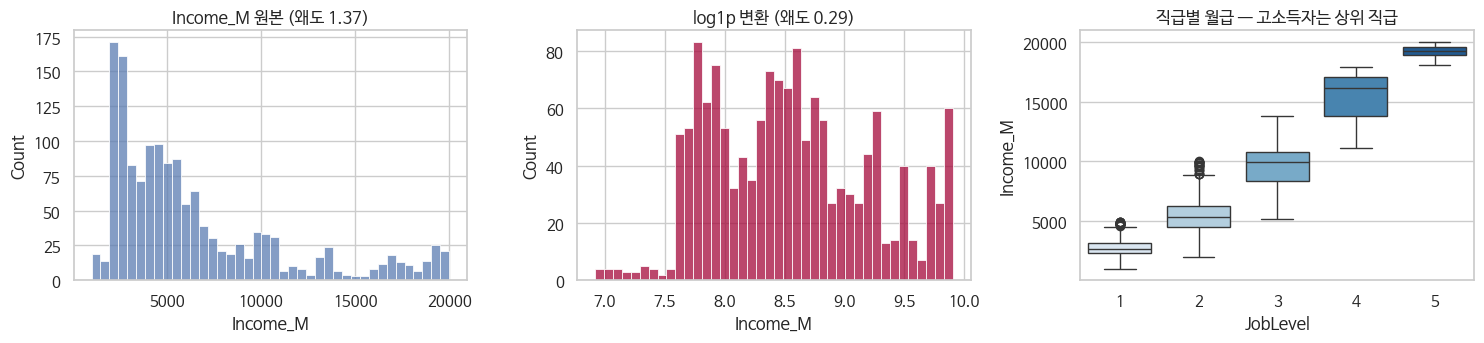

[판단] 위 세 번째 그래프에서 고소득 구간이 어느 직급에 몰려 있는지 확인하라.
       입력 오류라면 직급과 무관하게 흩어져 있어야 한다.

결정: ____________________________________  (직접 채워 넣을 것)
근거: ____________________________________


In [3]:
# TODO: 아래 세 그래프를 1행 3열로 그려라.
#   [0] Income_M 의 히스토그램 (제목에 왜도 skew() 값을 표시)
#   [1] np.log1p(Income_M) 의 히스토그램 (제목에 변환 후 왜도 표시)
#   [2] JobLevel 별 Income_M 의 boxplot
# 그린 뒤, 이상치를 제거할지 유지할지 결정하고 그 근거를 print 로 남겨라.
#   판단 힌트: 입력 오류라면 고소득자가 직급과 무관하게 흩어져 있을 것이다.


### 실습 1-2. 파생 피처 만들기 (도메인 지식)

원시 데이터에 없는 의미 있는 값을 만들어 낸다.
**주의**: 새 피처는 "있으면 좋다"가 아니다. 반드시 성능으로 검증해야 한다.


In [ ]:
def add_features(data):
    """도메인 지식 기반 파생 피처 생성 (원본을 변경하지 않는다)"""
    d = data.copy()
    # TODO: 아래 4개의 파생 피처를 만들어라
    #   PromotionStall : 승진 정체도  = YearsSinceLastPromotion / (YearsAtCompany + 1)
    #   JobHopRate     : 이직 성향    = Companies / max(Age - 18, 1)
    #   IncomeVsLevel  : 직급 대비 급여 = Income_M / (같은 JobLevel 의 Income_M 평균)
    #                    힌트: d.groupby("JobLevel")["Income_M"].transform("mean")
    #   BurnoutRisk    : 번아웃 위험  = (OverTime=="Yes") * (5 - WorkLifeBalance)
    return d


df_fe = add_features(df)
NEW_FEATURES = ["PromotionStall", "JobHopRate", "IncomeVsLevel", "BurnoutRisk"]

# TODO: 파생 피처가 실제로 신호를 담고 있는지 확인하라
#   1) Attrition 별 평균값 비교
#   2) Attrition 과의 상관계수


---
# 2. 데이터 누수 (Data Leakage) 실험

아래의 스케일링 기법을 검토해보자.

```python
sX = scaler.fit_transform(X)              # 전체를 한 번에 변환
X_train, X_valid, ... = train_test_split(sX, y, ...)
```

**이 순서는 “스케일링이 무엇을 하는가”를 보기 위한 단순화된 형태다.** 개념을 익히는 단계에서는
이 편이 코드가 짧고 이해도 쉽다. 실제로 이 데이터에서는 결과 차이도 거의 없다.

그런데 이 시스템은 **실제 운영에 활용되어야 한다.** 운영 시점에는 아직 존재하지도 않는 미래 데이터의
최솟값·최댓값을 미리 알 수 없다. 즉 위 코드는 **운영에서 재현할 수 없는 상황을 가정하고 있다.**

| | 기초 과정 (개념 이해) | 설계 과정 (운영 전제) |
|---|---|---|
| 목적 | 스케일링이 무엇인지 이해 | 학습 환경과 운영 환경을 일치시키기 |
| 순서 | 전체 변환 → 분할 | **분할 → 훈련으로만 fit → 양쪽 transform** |
| 문제 | 검증 데이터의 통계가 새어 들어감 | — |


> 그 차이가 실제로 얼마나 되는지 직접 측정해 보자.


### 실습 2-1. 두 순서의 검증 점수를 비교하라

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score

X_simple = df[NUM_COLS + ORD_COLS]
y = df[TARGET]

# TODO (A) 잘못된 순서를 재현하라
#   1) MinMaxScaler 로 X_simple 전체를 fit_transform
#   2) 그 결과를 train_test_split (test_size=0.3, random_state=RANDOM_STATE, stratify=y)
#   3) LogisticRegression(max_iter=1000, class_weight="balanced") 학습 후 검증 점수 출력

# TODO (B) 올바른 순서를 구현하라
#   1) 먼저 train_test_split (같은 설정)
#   2) 훈련 데이터로만 scaler.fit_transform, 검증 데이터에는 scaler.transform 만
#   3) 같은 모델을 학습해 검증 점수 출력

# 두 결과를 비교하라. 차이가 작게 나오더라도 그것은 정상이다.
# 그렇다면 왜 (B)를 써야 하는가? '운영 시점에 무엇을 알 수 없는가'로 답해 보라.


---
# 3. ColumnTransformer + Pipeline

전처리와 모델을 **하나의 객체**로 묶는다. 이 결정 하나가 6·7단계의 난이도를 결정한다.

| 이유 | 설명 |
|---|---|
| 누수 방지 | `fit` 이 훈련 데이터에서만 일어나도록 구조적으로 강제된다 |
| 교차검증 정합성 | 폴드마다 전처리가 다시 `fit` 된다 |
| 학습/서빙 일치 | 학습에 쓴 변환과 서빙에 쓸 변환이 **같은 객체**다 |
| 배포 단순화 | `joblib.dump(clf, "model.pkl")` 한 줄로 전처리+모델이 함께 저장된다 |


### 실습 3-1. 파이프라인 구성

- 수치형 → 중앙값 대체 + 스케일링
- 명목형 → 원-핫 인코딩 (`drop="first"`, `handle_unknown="ignore"`)
- 순서형 → 그대로 통과 (`passthrough`)

> `handle_unknown="ignore"` — 운영 데이터에 학습 때 없던 부서가 새로 생겨도 인코딩이 실패하지 않게 한다.
> 배포를 염두에 둔 코드는 처음부터 이런 상황을 처리해야 한다.



In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler

USE_FEATURES = True             # 파생 피처 사용 여부
data = df_fe if USE_FEATURES else df
NUM_ALL = NUM_COLS + (NEW_FEATURES if USE_FEATURES else [])

X = data[NUM_ALL + ORD_COLS + CAT_COLS]
y = data[TARGET]


def make_preprocessor(scaler=None):
    """컬럼 유형별 변환기를 하나로 묶는다."""
    scaler = MinMaxScaler() if scaler is None else scaler
    # TODO: ColumnTransformer 를 만들어 반환하라
    #   ("num", ...)  수치형(NUM_ALL): SimpleImputer(strategy="median") → scaler 순서의 Pipeline
    #   ("cat", ...)  명목형(CAT_COLS): OneHotEncoder(drop="first", handle_unknown="ignore")
    #   ("ord", ...)  순서형(ORD_COLS): "passthrough"
    return


pre = make_preprocessor()
print("입력 컬럼 수:", X.shape[1])
if pre is None:
    print("→ 아직 make_preprocessor() 가 비어 있습니다. 완성하거나 아래 구제 셀을 사용하세요.")
else:
    print("변환 후 컬럼 수:", pre.fit_transform(X).shape[1])

---
# 4. 데이터 세트 구성 — 분할과 교차검증

데이터 세트 구성의 5단계 중 ③ 샘플링(전수 사용) · ④ 분할 · ⑤ 불균형 해결을 여기서 처리한다.

`stratify=y` 를 빠뜨리면 소수 클래스가 16%뿐이므로 검증 세트의 퇴사자 비율이 12%나 20%로 흔들린다.
그러면 **모델 성능 차이인지 분할 운인지 구분할 수 없게 된다.**


In [ ]:
# TODO: train_test_split 으로 70:30 분할하라
#       (test_size=0.3, random_state=RANDOM_STATE, stratify=y)
#       분할 후 훈련/검증/전체의 퇴사 비율이 거의 같은지 확인해 출력하라
print(f"훈련: {X_train.shape}  퇴사 비율 {y_train.mean():.4f}")
print(f"검증: {X_valid.shape}  퇴사 비율 {y_valid.mean():.4f}")
print(f"전체:                 퇴사 비율 {y.mean():.4f}

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

demo = Pipeline([("pre", make_preprocessor()),
                 ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))])
scores = cross_val_score(demo, X_train, y_train, cv=cv, scoring="recall")
print("5-fold 재현율:", np.round(scores, 4))
print(f"평균 {scores.mean():.4f}  표준편차 {scores.std():.4f}")
print("\n※ 파이프라인을 통째로 넣었기 때문에 폴드마다 전처리가 다시 fit 된다 → 누수 없음")

---
# 5. 기준선 (Baseline) — 넘어야 할 선을 먼저 그린다

복잡한 모델부터 시작하면, 성능이 잘 나와도 "데이터가 좋아서인지 모델이 좋아서인지" 알 수 없다.
**세 가지 기준선**을 먼저 만든다.

**실행 전에 예상해 보라** — "전원 재직으로 예측"하는 모델의 정확도는 얼마일 것 같은가?
그리고 그 모델의 **재현율**은 얼마일까?


In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import precision_score, f1_score, roc_auc_score, confusion_matrix


def evaluate(name, y_true, y_pred, y_proba=None):
    """지표를 한 줄(dict)로 정리해 반환한다."""
    # TODO: 모델명 / 정확도 / 재현율 / 정밀도 / F1 / ROC-AUC 를 담은 dict 를 반환하라
    #       (zero_division=0 옵션을 사용해 경고를 피할 것)
    return {}


baselines = []
# TODO ① DummyClassifier(strategy="most_frequent") — 전원 재직으로 예측
# TODO ② DummyClassifier(strategy="stratified", random_state=RANDOM_STATE) — 비율대로 무작위
# TODO ③ 단일 규칙: X_valid["OverTime"] == "Yes" 이면 퇴사(1)로 예측

baseline_df = pd.DataFrame(baselines)
print("기준선 3종이 채워졌는지 확인:", len(baseline_df), "행")
baseline_df

> **읽는 법**
> 정확도 84%짜리 모델은 "아무것도 학습하지 않은 모델과 같다"는 뜻일 수 있다.
> 반대로 "OverTime 한 줄 규칙"이 재현율 0.5 를 낸다면, 그보다 낮은 재현율의 복잡한 모델은 존재 이유가 없다.


In [ ]:
# ─────────────────────────────────────────────────────────────
#  구제 셀 — evaluate() 와 기준선 3종
#  위 TODO 를 완성했다면 이 셀은 그냥 실행하고 지나가면 된다 (아무 일도 일어나지 않는다).
#  막혔다면 USE_RESCUE 를 True 로 바꾸고 실행한 뒤 다음 절로 진행한다.
#  ※ 제출 시 True 로 두어도 감점하지 않는다. 다만 어디서 막혔는지는 기록해 둘 것.
# ─────────────────────────────────────────────────────────────
USE_RESCUE = False

if USE_RESCUE:
    def evaluate(name, y_true, y_pred, y_proba=None):
        return {
            "모델": name,
            "정확도": round(accuracy_score(y_true, y_pred), 4),
            "재현율": round(recall_score(y_true, y_pred, zero_division=0), 4),
            "정밀도": round(precision_score(y_true, y_pred, zero_division=0), 4),
            "F1": round(f1_score(y_true, y_pred, zero_division=0), 4),
            "ROC-AUC": round(roc_auc_score(y_true, y_proba), 4) if y_proba is not None else np.nan,
        }

    baselines = []
    d1 = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
    baselines.append(evaluate("① 다수 클래스(전원 재직)", y_valid, d1.predict(X_valid),
                              d1.predict_proba(X_valid)[:, 1]))
    d2 = DummyClassifier(strategy="stratified", random_state=RANDOM_STATE).fit(X_train, y_train)
    baselines.append(evaluate("② 무작위(클래스 비율)", y_valid, d2.predict(X_valid),
                              d2.predict_proba(X_valid)[:, 1]))
    rule_pred = (X_valid["OverTime"] == "Yes").astype(int).values
    baselines.append(evaluate("③ 규칙(OverTime=Yes)", y_valid, rule_pred, rule_pred.astype(float)))
    print(pd.DataFrame(baselines).to_string(index=False))
    print('구제 코드를 사용했습니다 — evaluate() 와 기준선 3종')

---
# 6. 모델 비교 실험 (수업 · 핵심)

**한 번에 하나씩 바꾼다.** 여기서는 모델 종류만 바꾸고 나머지(분할·전처리·지표)는 모두 고정한다.

**실행 전에 예상해 보라** — 아래 7개 모델 중 **재현율**이 가장 높을 것 같은 모델은?
그리고 **정확도**가 가장 높을 것 같은 모델은? 두 답이 같은가, 다른가?


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

candidates = {
    "로지스틱 회귀":        LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "로지스틱(balanced)":   LogisticRegression(max_iter=1000, class_weight="balanced",
                                              random_state=RANDOM_STATE),
    "결정트리":             DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
    "랜덤 포레스트":        RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "그래디언트 부스팅":    GradientBoostingClassifier(random_state=RANDOM_STATE),
    "KNN (k=7)":            KNeighborsClassifier(n_neighbors=7),
    "선형 SVM":             CalibratedClassifierCV(LinearSVC(max_iter=5000,
                                                            random_state=RANDOM_STATE), cv=3),
}

results = list(baselines)
fitted = {}
# TODO: candidates 의 각 모델에 대해
#   1) Pipeline([("pre", make_preprocessor()), ("model", model)]) 를 만들고
#   2) X_train, y_train 으로 학습한 뒤
#   3) X_valid 에 대한 예측(pred)과 확률(proba[:, 1])을 구해
#   4) evaluate(...) 결과를 results 에 추가하고, 학습된 파이프라인을 fitted[name] 에 저장하라

model_table = pd.DataFrame(results)
if "재현율" in model_table.columns:
    model_table = model_table.sort_values("재현율", ascending=False).reset_index(drop=True)
else:
    print("→ 아직 결과가 비어 있습니다. 위 TODO 를 완성하거나 아래 구제 셀을 사용하세요.")
model_table

In [ ]:
# 정확도 순위와 재현율 순위가 어떻게 다른지 눈으로 확인
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
acc = model_table.sort_values("정확도", ascending=False)
rec = model_table.sort_values("재현율", ascending=False)
sns.barplot(data=acc, y="모델", x="정확도", ax=axes[0], palette="Blues_r")
axes[0].axvline(1 - y.mean(), color="#B26A00", ls="--", label="기준선 정확도")
axes[0].legend(); axes[0].set_title("정확도 순위")
sns.barplot(data=rec, y="모델", x="재현율", ax=axes[1], palette="rocket_r")
axes[1].set_title("재현율 순위 ← 우리의 요구사항")
plt.tight_layout(); plt.show()

print("두 순위를 비교해 보라. 예상과 맞았는가?")
print("정확도 1위 모델과 재현율 1위 모델이 다르다면, 우리는 어느 쪽을 골라야 하는가?")
print("→ 답은 1단계 요구사항 명세 카드의 '성능 우선순위' 항목에 이미 적혀 있다.")

---
# 7. 클래스 불균형 대응 비교

세 가지 접근을 **같은 모델·같은 분할**로 비교한다.

| 방법 | 설명 |
|---|---|
| 없음 | 아무 대응도 하지 않는다 |
| class_weight | 손실함수에서 소수 클래스의 오답에 더 큰 벌점 (데이터는 그대로) |
| SMOTE | 소수 클래스의 합성 샘플을 생성해 수를 늘린다 (**훈련 데이터에만**) |


In [ ]:
imb_results = []

# TODO (A) 대응 없음  : LogisticRegression(max_iter=1000) 만 사용
# TODO (B) class_weight="balanced" 추가
# TODO (C) SMOTE : imblearn.pipeline.Pipeline 으로
#          [("pre", make_preprocessor()), ("smote", SMOTE(random_state=RANDOM_STATE)),
#           ("model", LogisticRegression(max_iter=1000))]
#          ※ imblearn 이 없으면 !pip install -q imbalanced-learn
# 세 결과를 evaluate 로 평가해 imb_results 에 담아라

imb_table = pd.DataFrame(imb_results)
imb_table

### 실습 7-1. 재현율–정밀도 교환관계 확인

세 방법의 혼동행렬을 나란히 그려, **놓친 퇴사자(FN)** 와 **헛된 면담(FP)** 이 어떻게 맞바뀌는지 확인하라.


In [ ]:
# TODO: (A)(B)(C) 세 모델의 혼동행렬을 나란히 그려라.
#   힌트: from sklearn.metrics import ConfusionMatrixDisplay
#         cm = confusion_matrix(y_valid, model.predict(X_valid))
#         tn, fp, fn, tp = cm.ravel()
#   각 그래프의 제목에 FN(놓친 퇴사자)과 FP(헛된 면담) 개수를 표시할 것


---
# 8. 딥러닝(DNN) 비교  


## 먼저 예측해 보라 (실행 전에 답할 것)

지금까지 만든 로지스틱 회귀·랜덤 포레스트와 비교했을 때, **딥러닝은 몇 등쯤 할 것 같은가?**
그리고 그렇게 예상한 이유는 무엇인가?

| 판단 근거 | 이 사례의 조건 | 딥러닝에 유리한가? |
|---|---|---|
| 데이터 유형 | 정형(표 형태) 21개 피처 | ? |
| 데이터 규모 | 1,470건 | ? |
| 요구사항 | 예측 근거 설명 필요 | ? |
| 자원 | GPU 없음 | ? |

**예상: ______등 / 이유: ____________________**

---


In [ ]:
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
    TF_OK = True
except Exception as e:
    TF_OK = False
    print("TensorFlow 를 불러올 수 없습니다:", e)
    print("Colab 에서는 기본 설치되어 있습니다. 로컬이라면 !pip install tensorflow")

In [ ]:
if TF_OK:
    pre_dnn = make_preprocessor()
    Xtr_d = np.asarray(pre_dnn.fit_transform(X_train), dtype="float32")
    Xva_d = np.asarray(pre_dnn.transform(X_valid), dtype="float32")

    tf.random.set_seed(RANDOM_STATE)
    # TODO: Sequential 모델을 정의하라
    #   Dense(32, relu, input_shape=(Xtr_d.shape[1],)) → Dropout(0.3)
    #   → Dense(16, relu) → Dropout(0.2) → Dense(1, sigmoid)
    # TODO: compile — optimizer="adam", loss="binary_crossentropy",
    #                 metrics=["accuracy", tf.keras.metrics.Recall(name="recall")]
    # TODO: dnn.summary() 출력

In [ ]:
if TF_OK:
    # TODO 1) 소수 클래스 가중치 cw 를 계산하라
    #         cw = {0: len(y_train)/(2*n0), 1: len(y_train)/(2*n1)}
    # TODO 2) EarlyStopping(monitor="val_recall", mode="max", patience=20,
    #                       restore_best_weights=True)
    #         ModelCheckpoint("best_dnn.keras", monitor="val_recall", mode="max",
    #                         save_best_only=True)
    #         ※ 왜 val_loss 가 아니라 val_recall 을 기준으로 하는지 생각해 보라
    # TODO 3) dnn.fit(..., epochs=200, batch_size=32,
    #                 validation_data=(Xva_d, y_valid), class_weight=cw,
    #                 callbacks=[es, mc], verbose=0)
    pass

In [ ]:
if TF_OK:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for ax, key in zip(axes, ["loss", "recall"]):
        ax.plot(history.history[key], label="train")
        ax.plot(history.history["val_" + key], label="valid")
        ax.set_xlabel("epoch"); ax.set_ylabel(key); ax.legend(); ax.set_title(key)
    plt.tight_layout(); plt.show()

    dnn_proba = dnn.predict(Xva_d, verbose=0).ravel()
    dnn_pred = (dnn_proba >= 0.5).astype(int)
    dnn_row = evaluate("DNN (2 은닉층)", y_valid, dnn_pred, dnn_proba)
    print(pd.DataFrame([dnn_row]))

### [작성] 딥러닝과 머신러닝 모델 비교 결론

DNN 의 성능을 6절의 모델 비교표와 대조하고, 아래 질문에 답하라.

1. DNN 이 머신러닝 모델보다 나은가, 못한가? 수치로 말하라.
2. 그 이유는 무엇이라고 생각하는가? (데이터 규모 / 데이터 유형 / 과적합)
3. 성능이 비슷하다면 어떤 모델을 선택해야 하는가? 1단계 요구사항을 근거로 답하라.
4. 이 결론이 5차시의 시각 검색 문제에도 그대로 적용될까? 무엇이 달라지면 결론이 뒤집히는가?

**결론**:


---
# 9. 모델 해석과 저장

1단계에서 "인사팀이 예측 근거를 설명할 수 있어야 한다"고 합의했다. 그 요구사항을 이행한다.


In [ ]:
best_pipe = fitted["로지스틱(balanced)"]

# TODO 1) best_pipe.named_steps["pre"].get_feature_names_out() 으로 변환 후 피처 이름을 얻어라
# TODO 2) best_pipe.named_steps["model"].coef_[0] 로 계수를 얻어라
# TODO 3) 계수의 절댓값이 큰 순으로 정렬해 상위 15개를 수평 막대그래프로 그려라
#         (양수는 퇴사 확률을 높이는 방향, 음수는 낮추는 방향 — 색을 다르게)
# TODO 4) 2차시 EDA 결론과 일치하는지 확인하라


In [ ]:
# 〔선택〕 순열 중요도 — 모델 종류와 무관하게 사용할 수 있다
from sklearn.inspection import permutation_importance

perm = permutation_importance(best_pipe, X_valid, y_valid, scoring="recall",
                              n_repeats=10, random_state=RANDOM_STATE)
perm_df = (pd.DataFrame({"피처": X_valid.columns, "중요도": perm.importances_mean})
           .sort_values("중요도", ascending=False).reset_index(drop=True))
perm_df.head(10)

### 실습 9-1. 파이프라인 저장 (4차시에서 사용)

`joblib.dump()` 한 줄로 **전처리 + 모델이 함께** 저장된다. 이것이 3절에서 파이프라인으로 묶은 이유다.


In [ ]:
import joblib, json, datetime

# TODO 1) best_pipe 를 "hr_attrition_v1.pkl" 로 저장하라 (joblib.dump)
# TODO 2) 아래 정보를 담은 메타데이터를 "hr_attrition_v1.meta.json" 으로 저장하라
#         model_version, algorithm, trained_at, random_state, threshold,
#         input_columns, valid_accuracy, valid_recall, valid_precision,
#         valid_roc_auc, baseline_accuracy
#         ※ 4차시 실습이 이 두 파일을 불러와서 시작한다


In [ ]:
# ─────────────────────────────────────────────────────────────
#  구제 셀 — 파이프라인 저장 (4차시 전제조건)
#  위 TODO 를 완성했다면 이 셀은 그냥 실행하고 지나가면 된다 (아무 일도 일어나지 않는다).
#  막혔다면 USE_RESCUE 를 True 로 바꾸고 실행한 뒤 다음 절로 진행한다.
#  ※ 제출 시 True 로 두어도 감점하지 않는다. 다만 어디서 막혔는지는 기록해 둘 것.
# ─────────────────────────────────────────────────────────────
USE_RESCUE = False

if USE_RESCUE:
    import joblib, json, datetime

    final_row = [r for r in results if r["모델"] == "로지스틱(balanced)"][0]
    meta = {
        "model_version": "v1",
        "algorithm": "LogisticRegression(class_weight='balanced', max_iter=1000)",
        "trained_at": str(datetime.date.today()),
        "random_state": RANDOM_STATE,
        "threshold": 0.5,
        "input_columns": list(X.columns),
        "use_derived_features": USE_FEATURES,
        "valid_accuracy": final_row["정확도"],
        "valid_recall": final_row["재현율"],
        "valid_precision": final_row["정밀도"],
        "valid_roc_auc": final_row["ROC-AUC"],
        "baseline_accuracy": round(1 - y.mean(), 4),
    }
    joblib.dump(best_pipe, "hr_attrition_v1.pkl")
    with open("hr_attrition_v1.meta.json", "w", encoding="utf-8") as f:
        json.dump(meta, f, ensure_ascii=False, indent=2)
    print("저장 완료 — 이 두 파일이 있어야 4차시 실습을 시작할 수 있다")


In [ ]:
# 저장한 파일이 실제로 동작하는지 확인 (배포 전 필수 점검)
loaded = joblib.load("hr_attrition_v1.pkl")
same = (loaded.predict_proba(X_valid)[:, 1] == best_pipe.predict_proba(X_valid)[:, 1]).all()
print("저장→로드 후 예측 일치:", "일치!" if same else "일치하지 않음!")

# 원본 형태의 DataFrame 한 건만 넣어도 동작하는가? (서빙 상황 모사)
one = X_valid.iloc[[0]]
print("단건 예측 확률:", round(float(loaded.predict_proba(one)[:, 1][0]), 4))

---
# 산출물 ④ 모델 카드 (Model Card)

아래 양식을 채워라. **"알려진 한계"와 "사용 조건"이 모델 카드의 핵심**이다.
성능 수치만 적힌 문서는 보고서이지 설계 문서가 아니다.

## 모델 카드

- **모델 이름** :
- **알고리즘** :
- **전처리** :
- **파생 피처** :
- **학습 데이터** :
- **검증 데이터** :
- **성능(검증)** :
- **기준선 대비** :
- **선택 이유** :
- **주요 피처** :
- **알려진 한계** :
- **사용 조건** :

---
# 제출

1. 모든 TODO 셀을 채우고 **런타임 → 모두 실행**이 오류 없이 끝나는지 확인한다.
2. **모델 비교 실험표**, **불균형 대응 비교표**, **모델 카드**가 모두 포함되었는지 확인한다.
3. `.ipynb` 파일과 `hr_attrition_v1.pkl`, `hr_attrition_v1.meta.json` 을 함께 제출한다.

## 다음 차시 (4차시) 예고

오늘 저장한 파이프라인을 불러와 5~7단계로 간다.
- 지표를 제대로 고르고, **임계값을 비용으로 결정**한다
- 민감 속성 그룹별 **공정성**을 측정한다
- 모델을 **배치 예측 서비스**로 만들고, **드리프트**를 감지해 재학습 시점을 판단한다
